<a href="https://colab.research.google.com/github/oerv13-gh/Ibero/blob/main/Clase_Semana6_ANN_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clase Semana 5**



# **Ejemplo 1 (CNN)**

In [1]:
# Importar librerías

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import time

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
# Cargar las 3 bases de datos

from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10

# Cargar datasets
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
(fashion_x_train, fashion_y_train), (fashion_x_test, fashion_y_test) = fashion_mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()

# Nombres de clases
mnist_class_names = [str(i) for i in range(10)]

fashion_class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

cifar_class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("MNIST:", mnist_x_train.shape, mnist_y_train.shape)
print("Fashion-MNIST:", fashion_x_train.shape, fashion_y_train.shape)
print("CIFAR-10:", cifar_x_train.shape, cifar_y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
MNIST: (60000, 28, 28) (60000,)
Fashion-MNIST: (60000, 28, 28) (60000,)
CIFAR-10: (50000, 32, 32, 3) (50000, 1)


In [3]:
# Función para mostrar 6 imágenes de cada dataset

def mostrar_imagenes(x, y, class_names, titulo, n=6, cmap='gray'):
    plt.figure(figsize=(14, 3))
    indices = np.random.choice(len(x), n, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(1, n, i + 1)
        if x[idx].ndim == 2:
            plt.imshow(x[idx], cmap=cmap)
        else:
            plt.imshow(x[idx])
        etiqueta = y[idx] if np.isscalar(y[idx]) else y[idx][0]
        plt.title(class_names[etiqueta], fontsize=10)
        plt.axis("off")

    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

In [4]:
# Seleccionar cuál dataset entrenar

DATASET_ACTIVO = "fashion"   # cambiar por: "mnist", "fashion", "cifar10"

In [5]:
# Preparar el dataset seleccionado

def preparar_dataset(nombre_dataset, max_train=12000, max_test=3000):
    if nombre_dataset == "mnist":
        x_train, y_train = mnist_x_train.copy(), mnist_y_train.copy()
        x_test, y_test = mnist_x_test.copy(), mnist_y_test.copy()
        class_names = mnist_class_names

    elif nombre_dataset == "fashion":
        x_train, y_train = fashion_x_train.copy(), fashion_y_train.copy()
        x_test, y_test = fashion_x_test.copy(), fashion_y_test.copy()
        class_names = fashion_class_names

    elif nombre_dataset == "cifar10":
        x_train, y_train = cifar_x_train.copy(), cifar_y_train.copy().flatten()
        x_test, y_test = cifar_x_test.copy(), cifar_y_test.copy().flatten()
        class_names = cifar_class_names

    else:
        raise ValueError("Dataset no reconocido")

    # Normalizar
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    # Agregar canal si son imágenes en escala de grises
    if x_train.ndim == 3:
        x_train = np.expand_dims(x_train, -1)
        x_test = np.expand_dims(x_test, -1)

    # Reducir tamaño para entrenar rápido
    x_train = x_train[:max_train]
    y_train = y_train[:max_train]
    x_test = x_test[:max_test]
    y_test = y_test[:max_test]

    return x_train, y_train, x_test, y_test, class_names

x_train, y_train, x_test, y_test, class_names = preparar_dataset(DATASET_ACTIVO)

print("Dataset activo:", DATASET_ACTIVO)
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("Número de clases:", len(class_names))

Dataset activo: fashion
x_train: (12000, 28, 28, 1)
x_test : (3000, 28, 28, 1)
Número de clases: 10


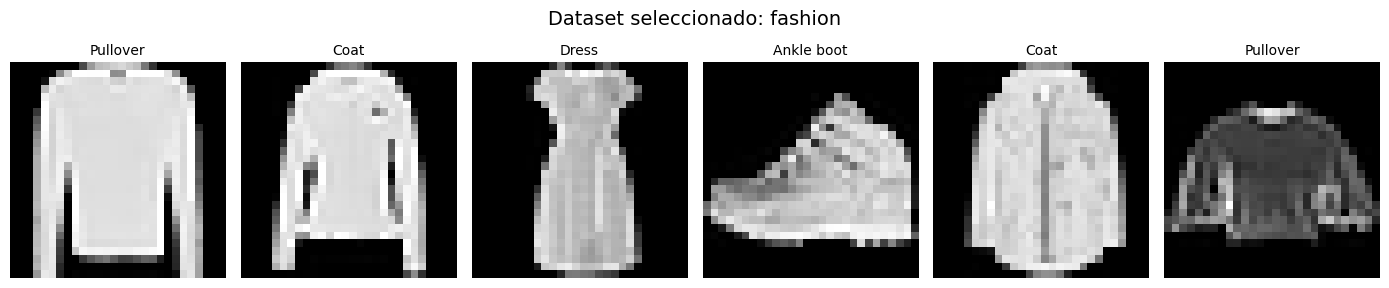

In [6]:
# Visualizar nuevamente 6 imágenes del dataset elegido

mostrar_imagenes(
    (x_train * 255).astype(np.uint8).squeeze(),
    y_train,
    class_names,
    f"Dataset seleccionado: {DATASET_ACTIVO}",
    n=6,
    cmap='gray' if x_train.shape[-1] == 1 else None
)

In [16]:
# Definir espacio o universo para la optimización random search

import random

def sample_hyperparams():
    return {
        "filters1": random.choice([16, 32, 64]),
        "filters2": random.choice([32, 64, 128]),
        "filters3": random.choice([64, 128, 256]),
        "dense_units": random.choice([32, 64, 128]),
        "dropout": random.choice([0.2, 0.3, 0.5]),
        "learning_rate": random.choice([1e-2, 1e-3, 5e-4]),
        "batch_size": random.choice([16, 32, 64]),
        "epochs": random.choice([10, 15, 20])
    }

In [17]:
from tensorflow.keras import layers, models, optimizers

def crear_cnn_hp(input_shape, num_classes, hp):
    model = models.Sequential([
        layers.Conv2D(hp["filters1"], (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(hp["filters2"], (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(hp["filters3"], (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(hp["dense_units"], activation='relu'),
        layers.Dropout(hp["dropout"]),
        layers.Dense(num_classes, activation='softmax')
    ])

    optimizer = optimizers.Adam(learning_rate=hp["learning_rate"])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [18]:
import pandas as pd

def random_search_cnn(X_train, y_train, X_val, y_val, input_shape, num_classes, n_trials=3):

    resultados = []

    for i in range(n_trials):
        print(f"\n🔁 Corrida {i+1}/{n_trials}")

        hp = sample_hyperparams()
        print("📌 Hiperparámetros:", hp)

        model = crear_cnn_hp(input_shape, num_classes, hp)

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=hp["epochs"],
            batch_size=hp["batch_size"],
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])
        train_acc = max(history.history['accuracy'])

        print(f"✅ Train Acc: {train_acc:.4f}")
        print(f"📊 Val Acc: {val_acc:.4f}")

        resultados.append({
            "trial": i+1,
            "val_accuracy": val_acc,
            "train_accuracy": train_acc,
            **hp
        })

    df_resultados = pd.DataFrame(resultados).sort_values(by="val_accuracy", ascending=False)

    print("\n🏆 Mejor configuración encontrada:")
    print(df_resultados.iloc[0])

    return df_resultados

In [19]:
df_resultados = random_search_cnn(
    x_train, y_train,
    x_test, y_test,
    input_shape=input_shape,
    num_classes=10,
    n_trials=3
)


🔁 Corrida 1/3
📌 Hiperparámetros: {'filters1': 64, 'filters2': 128, 'filters3': 128, 'dense_units': 32, 'dropout': 0.5, 'learning_rate': 0.01, 'batch_size': 32, 'epochs': 10}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Train Acc: 0.6013
📊 Val Acc: 0.7213

🔁 Corrida 2/3
📌 Hiperparámetros: {'filters1': 16, 'filters2': 128, 'filters3': 256, 'dense_units': 128, 'dropout': 0.3, 'learning_rate': 0.01, 'batch_size': 32, 'epochs': 15}
✅ Train Acc: 0.9017
📊 Val Acc: 0.8673

🔁 Corrida 3/3
📌 Hiperparámetros: {'filters1': 32, 'filters2': 64, 'filters3': 128, 'dense_units': 128, 'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20}
✅ Train Acc: 0.8474
📊 Val Acc: 0.8537

🏆 Mejor configuración encontrada:
trial               2.000000
val_accuracy        0.867333
train_accuracy      0.901667
filters1           16.000000
filters2          128.000000
filters3          256.000000
dense_units       128.000000
dropout             0.300000
learning_rate       0.010000
batch_size         32.000000
epochs             15.000000
Name: 1, dtype: float64


In [7]:
# Crear un modelo MLP básico

def crear_mlp(input_shape, num_classes):
    model = models.Sequential([
        layers.Flatten(input_shape=input_shape),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [8]:
# Crear un modelo CNN básico

def crear_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [9]:
# Entrenar ambos modelos

input_shape = x_train.shape[1:]
num_classes = len(class_names)

mlp = crear_mlp(input_shape, num_classes)
cnn = crear_cnn(input_shape, num_classes)

print("Entrenando MLP...")
inicio_mlp = time.time()
hist_mlp = mlp.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)
tiempo_mlp = time.time() - inicio_mlp

print("\nEntrenando CNN...")
inicio_cnn = time.time()
hist_cnn = cnn.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)
tiempo_cnn = time.time() - inicio_cnn

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando MLP...
Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6808 - loss: 0.9285 - val_accuracy: 0.7950 - val_loss: 0.5800
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7929 - loss: 0.5920 - val_accuracy: 0.8408 - val_loss: 0.4829
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8147 - loss: 0.5244 - val_accuracy: 0.8471 - val_loss: 0.4449
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8308 - loss: 0.4764 - val_accuracy: 0.8383 - val_loss: 0.4442
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8392 - loss: 0.4464 - val_accuracy: 0.8600 - val_loss: 0.4061
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8451 - loss: 0.4210 - val_accuracy: 0.8571 - val_loss: 0.4095
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8481 - loss: 0.4057 - val_accuracy: 0.8608 - val_loss: 0.3886
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8657 - loss: 0.3793

In [10]:
# Evaluar modelos

loss_mlp, acc_mlp = mlp.evaluate(x_test, y_test, verbose=0)
loss_cnn, acc_cnn = cnn.evaluate(x_test, y_test, verbose=0)

print("Resultados finales")
print("-" * 40)
print(f"MLP  -> Accuracy: {acc_mlp:.4f} | Loss: {loss_mlp:.4f} | Tiempo: {tiempo_mlp:.2f} s")
print(f"CNN  -> Accuracy: {acc_cnn:.4f} | Loss: {loss_cnn:.4f} | Tiempo: {tiempo_cnn:.2f} s")

Resultados finales
----------------------------------------
MLP  -> Accuracy: 0.8583 | Loss: 0.3912 | Tiempo: 12.73 s
CNN  -> Accuracy: 0.8117 | Loss: 0.5018 | Tiempo: 617.69 s


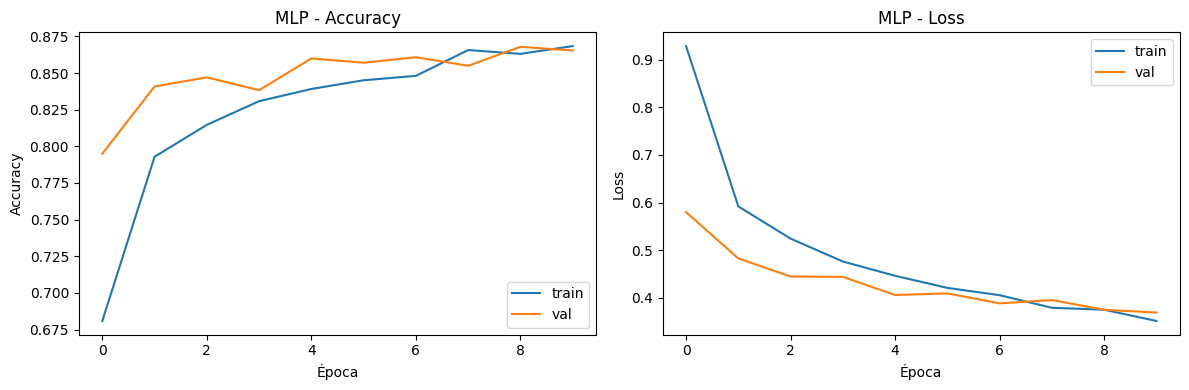

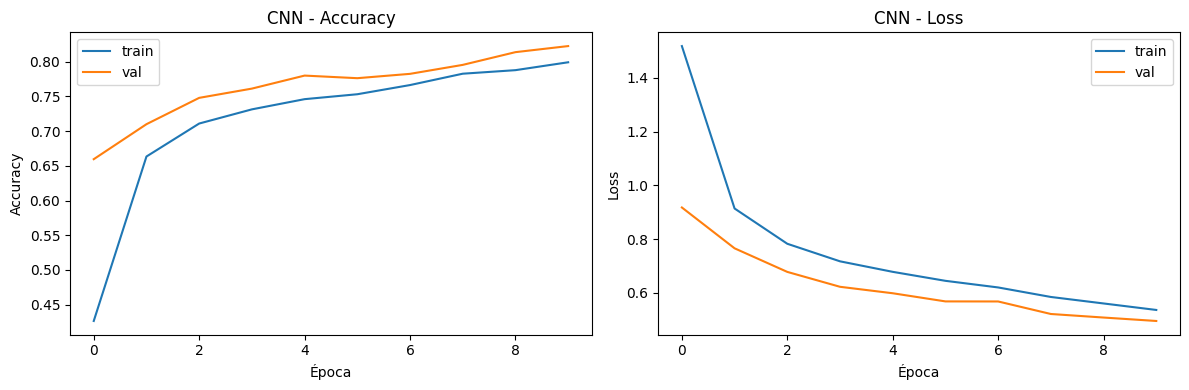

In [11]:
# Graficar curvas de entrenamiento

def graficar_historial(historia, titulo):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(historia.history['accuracy'], label='train')
    plt.plot(historia.history['val_accuracy'], label='val')
    plt.title(f'{titulo} - Accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(historia.history['loss'], label='train')
    plt.plot(historia.history['val_loss'], label='val')
    plt.title(f'{titulo} - Loss')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

graficar_historial(hist_mlp, "MLP")
graficar_historial(hist_cnn, "CNN")

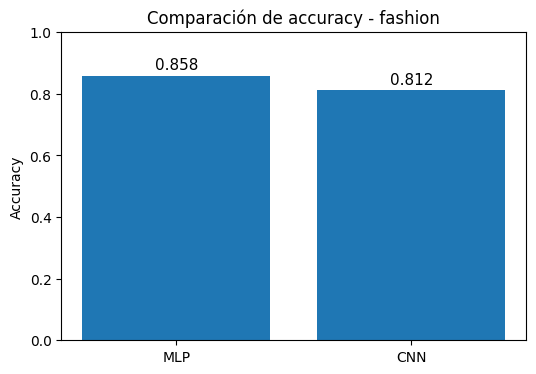

In [12]:
# Comparación visual de accuracy final

modelos = ["MLP", "CNN"]
accuracies = [acc_mlp, acc_cnn]

plt.figure(figsize=(6,4))
plt.bar(modelos, accuracies)
plt.ylim(0, 1)
plt.title(f"Comparación de accuracy - {DATASET_ACTIVO}")
plt.ylabel("Accuracy")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=11)
plt.show()

<Figure size 800x800 with 0 Axes>

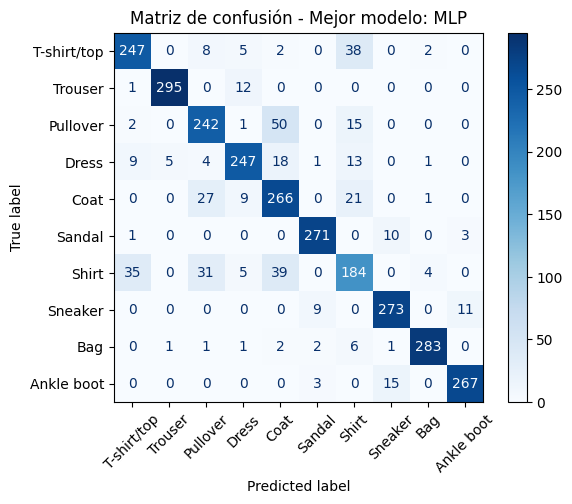

In [13]:
# Matriz de confusión del mejor modelo

mejor_modelo = cnn if acc_cnn >= acc_mlp else mlp
nombre_mejor = "CNN" if acc_cnn >= acc_mlp else "MLP"

pred = np.argmax(mejor_modelo.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d')
plt.title(f"Matriz de confusión - Mejor modelo: {nombre_mejor}")
plt.show()

In [14]:
# Reporte de clasificación

print(f"Mejor modelo: {nombre_mejor}\n")
print(classification_report(y_test, pred, target_names=class_names))

Mejor modelo: MLP

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.82      0.83       302
     Trouser       0.98      0.96      0.97       308
    Pullover       0.77      0.78      0.78       310
       Dress       0.88      0.83      0.85       298
        Coat       0.71      0.82      0.76       324
      Sandal       0.95      0.95      0.95       285
       Shirt       0.66      0.62      0.64       298
     Sneaker       0.91      0.93      0.92       293
         Bag       0.97      0.95      0.96       297
  Ankle boot       0.95      0.94      0.94       285

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



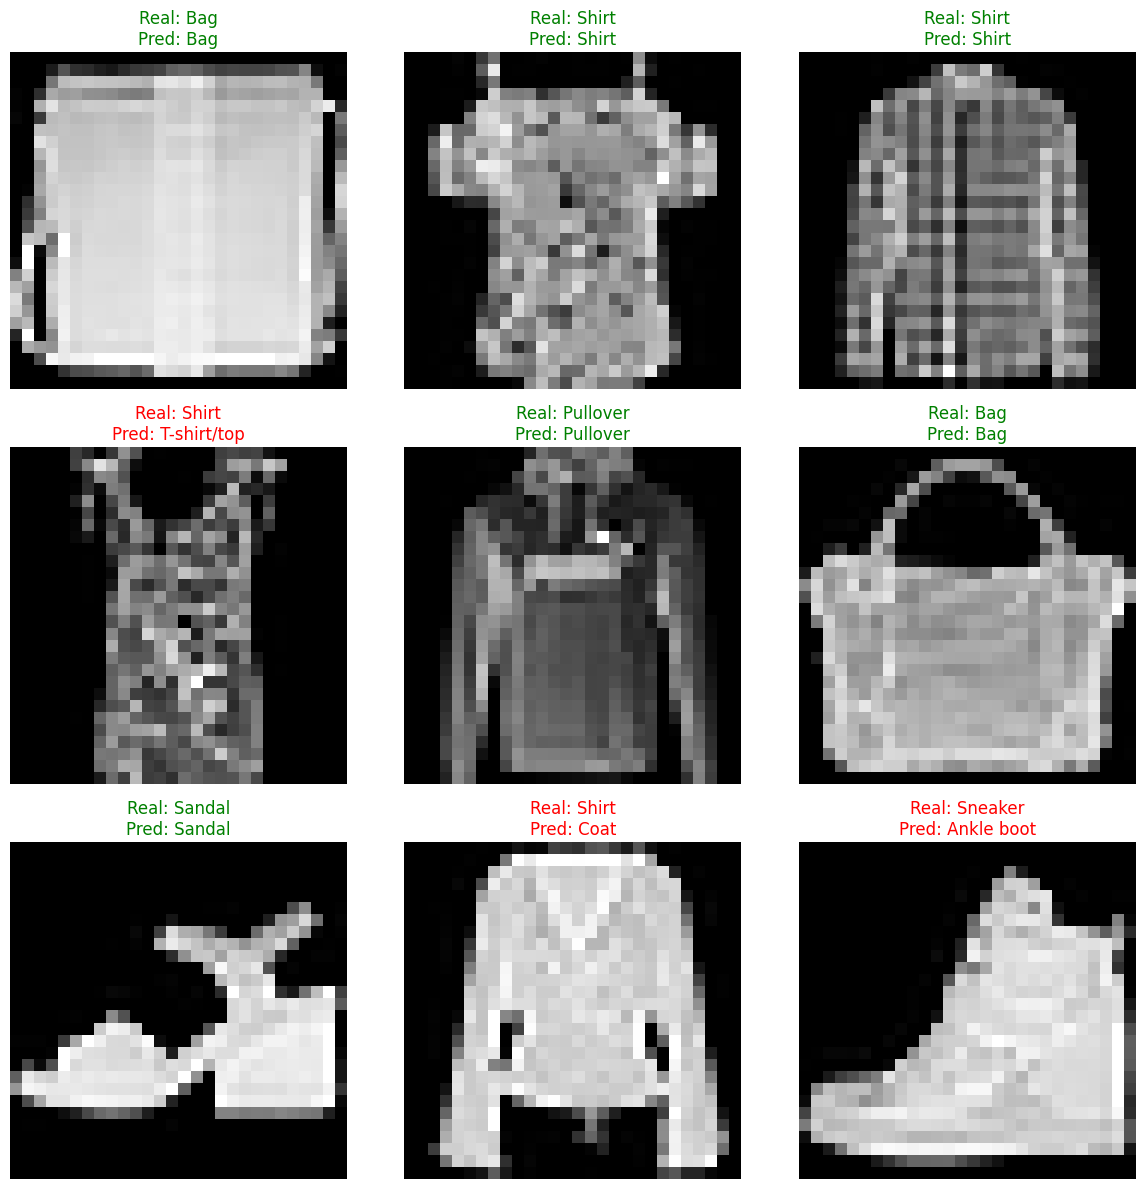

In [15]:
# Mostrar predicciones sobre 9 imágenes

indices = np.random.choice(len(x_test), 9, replace=False)

plt.figure(figsize=(12,12))
for i, idx in enumerate(indices):
    plt.subplot(3,3,i+1)

    if x_test[idx].shape[-1] == 1:
        plt.imshow(x_test[idx].squeeze(), cmap='gray')
    else:
        plt.imshow(x_test[idx])

    prediccion = np.argmax(mejor_modelo.predict(np.expand_dims(x_test[idx], axis=0), verbose=0), axis=1)[0]
    real = y_test[idx]

    color_titulo = "green" if prediccion == real else "red"
    plt.title(f"Real: {class_names[real]}\nPred: {class_names[prediccion]}", color=color_titulo)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Ejemplo 2 (MLP)**

--- Muestra de la Base de Datos Real (California Housing) ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   

   Longitude  MedHouseVal  Clase_Precio  
0    -122.23        4.526             1  
1    -122.22        3.585             1  
2    -122.24        3.521             1  
3    -122.25        3.413             1  
4    -122.25        3.422             1  
5    -122.25        2.697             1  


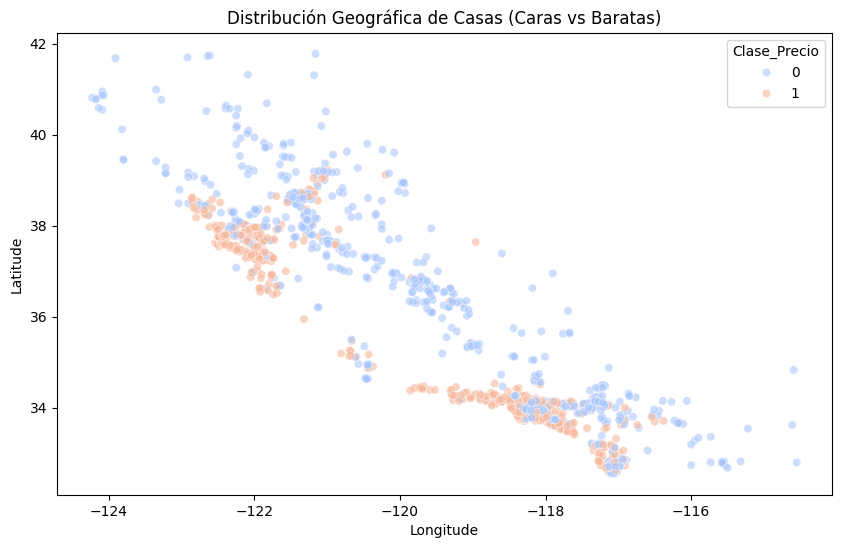

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Cargar el Dataset Real
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Clasificación: 1 si el precio es mayor a la mediana, 0 si es menor
mediana = df['MedHouseVal'].median()
df['Clase_Precio'] = (df['MedHouseVal'] > mediana).astype(int)

# 2. Visualización de los datos (Muestra de 6 filas)
print("--- Muestra de la Base de Datos Real (California Housing) ---")
print(df.head(6))

# Visualizar la distribución por Ubicación (Latitud y Longitud)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='Longitude', y='Latitude',
                hue='Clase_Precio', palette='coolwarm', alpha=0.6)
plt.title("Distribución Geográfica de Casas (Caras vs Baratas)")
plt.show()

In [ ]:
X = df.drop(['MedHouseVal', 'Clase_Precio'], axis=1)
y = df['Clase_Precio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def crear_mlp():
    model = models.Sequential([
        layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid') # Clasificación Binaria
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

mlp_model = crear_mlp()
print("\n--- Entrenando Arquitectura A: MLP (Rápido) ---")
history_mlp = mlp_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
print(f"Precisión Final MLP: {history_mlp.history['val_accuracy'][-1]:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Entrenando Arquitectura A: MLP (Rápido) ---
Precisión Final MLP: 0.85


In [ ]:
def crear_robusta():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dropout(0.2), # Apaga neuronas al azar para mejorar aprendizaje
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

robusta_model = crear_robusta()
print("\n--- Entrenando Arquitectura B: Robusta con Dropout ---")
history_robusta = robusta_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
print(f"Precisión Final Robusta: {history_robusta.history['val_accuracy'][-1]:.2f}")


--- Entrenando Arquitectura B: Robusta con Dropout ---
Precisión Final Robusta: 0.85


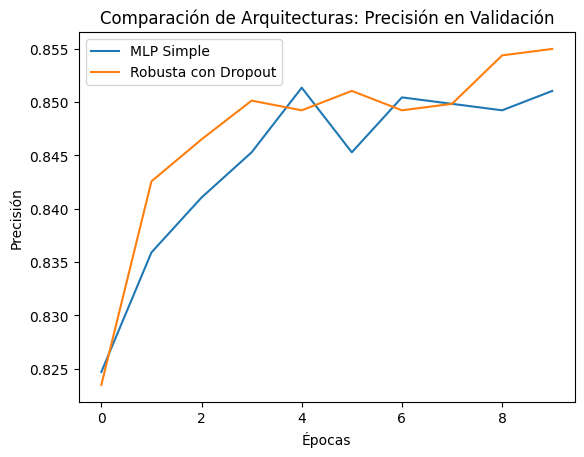

In [ ]:
plt.plot(history_mlp.history['val_accuracy'], label='MLP Simple')
plt.plot(history_robusta.history['val_accuracy'], label='Robusta con Dropout')
plt.title('Comparación de Arquitecturas: Precisión en Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# **Ejemplo 3 (CNN)**


In [ ]:
# Instalar Kaggle

!pip -q install kagglehub

In [ ]:
# Librerías

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
# Descargar Dataset

# Descarga del dataset desde Kaggle
#path = kagglehub.dataset_download("kelvingothman/house-typestyle-detection")

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Ruta descargada:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Ruta descargada: /kaggle/input/intel-image-classification


In [ ]:
# Explorar carpetas

root = Path(path)

for p in root.rglob("*"):
    if p.is_dir():
        print(p)

/kaggle/input/intel-image-classification/seg_train
/kaggle/input/intel-image-classification/seg_pred
/kaggle/input/intel-image-classification/seg_test
/kaggle/input/intel-image-classification/seg_train/seg_train
/kaggle/input/intel-image-classification/seg_pred/seg_pred
/kaggle/input/intel-image-classification/seg_test/seg_test
/kaggle/input/intel-image-classification/seg_train/seg_train/mountain
/kaggle/input/intel-image-classification/seg_train/seg_train/street
/kaggle/input/intel-image-classification/seg_train/seg_train/buildings
/kaggle/input/intel-image-classification/seg_train/seg_train/sea
/kaggle/input/intel-image-classification/seg_train/seg_train/forest
/kaggle/input/intel-image-classification/seg_train/seg_train/glacier
/kaggle/input/intel-image-classification/seg_test/seg_test/mountain
/kaggle/input/intel-image-classification/seg_test/seg_test/street
/kaggle/input/intel-image-classification/seg_test/seg_test/buildings
/kaggle/input/intel-image-classification/seg_test/seg_te

In [ ]:
# Detectar carpetas de clases

def encontrar_directorio_clases(root_path):
    """
    Busca una carpeta que contenga subcarpetas con imágenes.
    """
    root_path = Path(root_path)
    extensiones = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    candidatos = []
    for carpeta in root_path.rglob("*"):
        if carpeta.is_dir():
            subdirs = [d for d in carpeta.iterdir() if d.is_dir()]
            if len(subdirs) >= 2:
                total_imgs = 0
                for sd in subdirs:
                    total_imgs += len([f for f in sd.rglob("*") if f.suffix.lower() in extensiones])
                if total_imgs > 0:
                    candidatos.append((carpeta, len(subdirs), total_imgs))

    candidatos = sorted(candidatos, key=lambda x: x[2], reverse=True)

    if not candidatos:
        raise ValueError("No se encontró una carpeta con subcarpetas de clases e imágenes.")

    print("Posibles carpetas de clases encontradas:\n")
    for c in candidatos[:10]:
        print(f"Carpeta: {c[0]} | Clases: {c[1]} | Imágenes: {c[2]}")

    return candidatos[0][0]

data_dir = encontrar_directorio_clases(root)
print("\nCarpeta seleccionada:", data_dir)

Posibles carpetas de clases encontradas:

Carpeta: /kaggle/input/intel-image-classification/seg_train/seg_train | Clases: 6 | Imágenes: 14034
Carpeta: /kaggle/input/intel-image-classification/seg_test/seg_test | Clases: 6 | Imágenes: 3000

Carpeta seleccionada: /kaggle/input/intel-image-classification/seg_train/seg_train


In [ ]:
# Revisar clases

extensiones = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_names = sorted([d.name for d in Path(data_dir).iterdir() if d.is_dir()])
print("Clases encontradas:", class_names)

conteo_por_clase = {}
for clase in class_names:
    carpeta_clase = Path(data_dir) / clase
    n_imgs = len([f for f in carpeta_clase.rglob("*") if f.suffix.lower() in extensiones])
    conteo_por_clase[clase] = n_imgs

print("\nNúmero de imágenes por clase:")
for clase, n in conteo_por_clase.items():
    print(f"{clase}: {n}")

Clases encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Número de imágenes por clase:
buildings: 2191
forest: 2271
glacier: 2404
mountain: 2512
sea: 2274
street: 2382


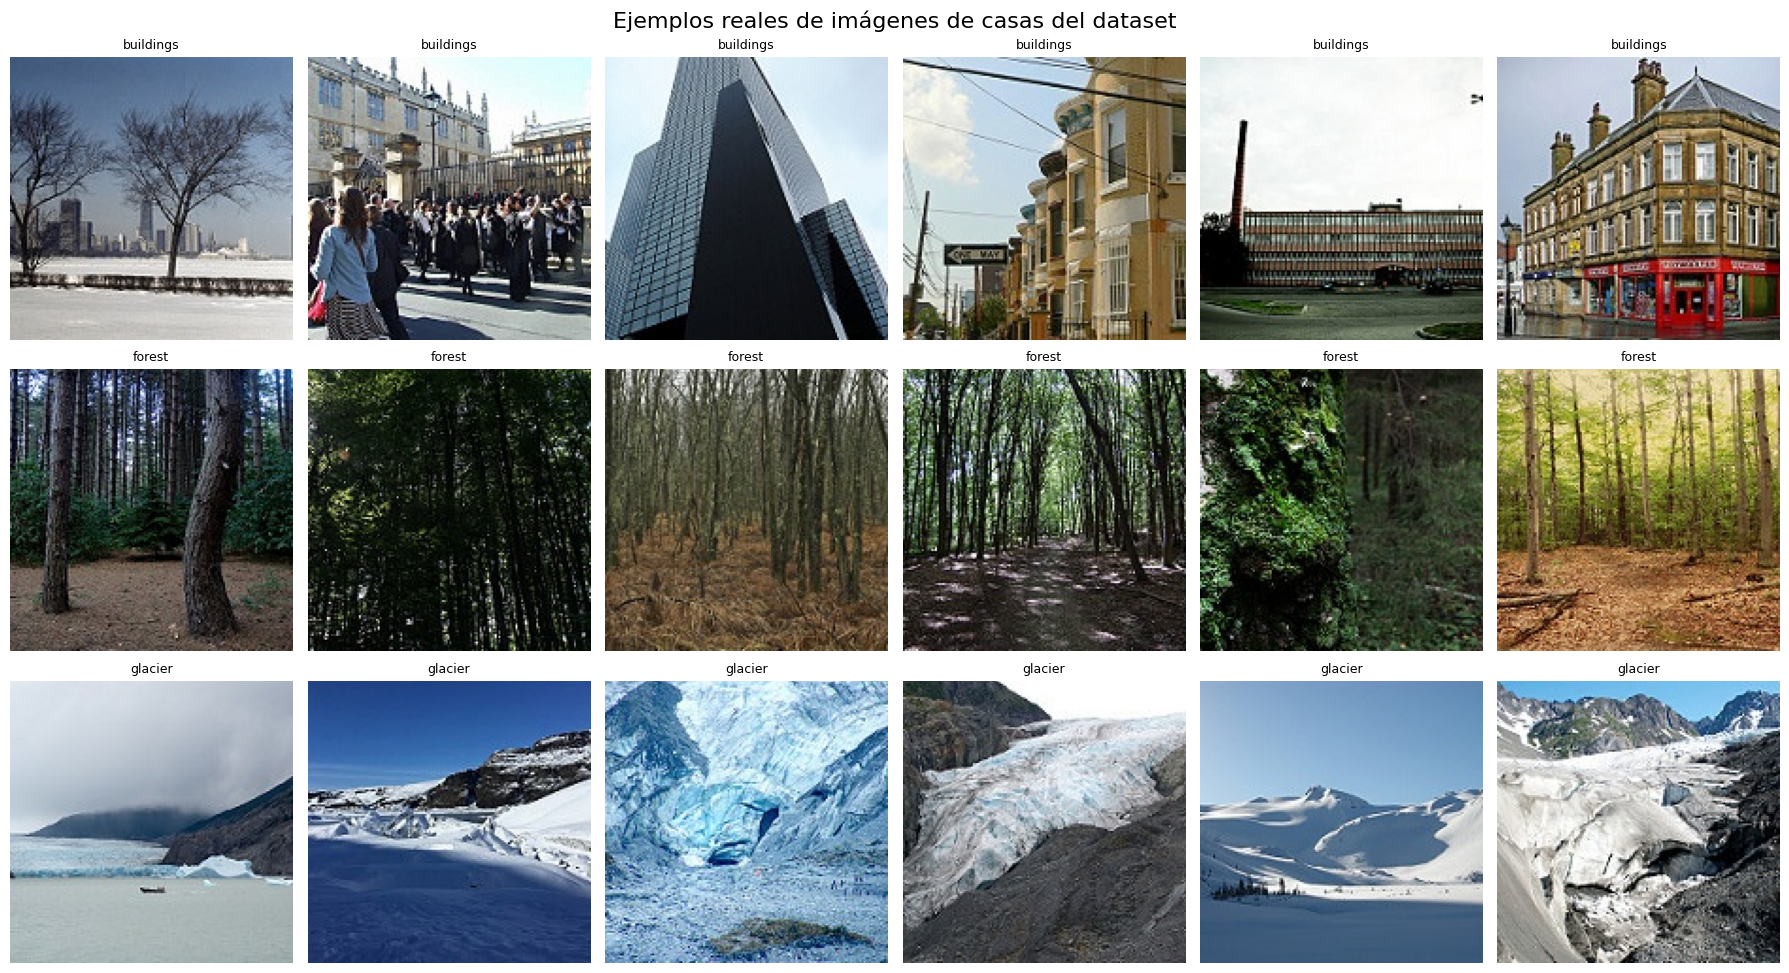

In [ ]:
#Mostrar imagenes dataset

def obtener_imagenes_clase(data_dir, clase, max_imgs=6):
    carpeta = Path(data_dir) / clase
    imgs = [f for f in carpeta.rglob("*") if f.suffix.lower() in extensiones]
    random.shuffle(imgs)
    return imgs[:max_imgs]

plt.figure(figsize=(18, 10))
plot_idx = 1

for clase in class_names[:min(len(class_names), 3)]:  # muestra hasta 3 clases
    imagenes = obtener_imagenes_clase(data_dir, clase, max_imgs=6)
    for img_path in imagenes:
        img = plt.imread(img_path)
        plt.subplot(min(len(class_names), 3), 6, plot_idx)
        plt.imshow(img)
        plt.title(clase, fontsize=9)
        plt.axis("off")
        plot_idx += 1

plt.suptitle("Ejemplos reales de imágenes de casas del dataset", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Dataset entrenamiento y validacion

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Clases finales:", class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Clases finales: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# Carga dataset

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

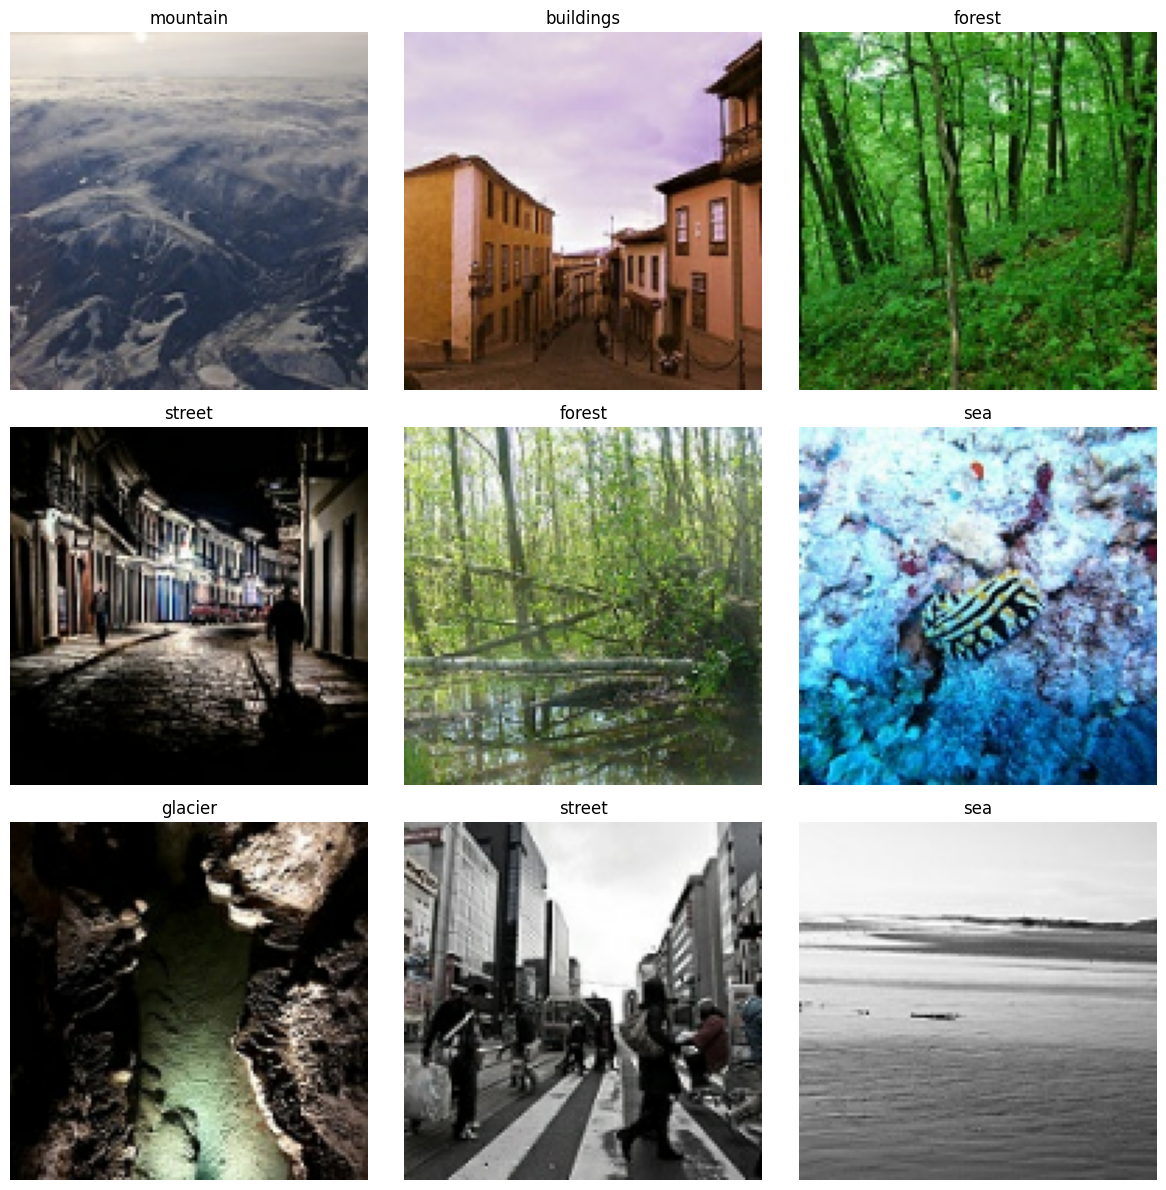

In [ ]:
# Muestra de 1 lote de imagenes cargadas

plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Construir modelo CNN

num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,454 (16.36 MB)

 Trainable params: 4,288,454 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar modelo CNN

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 425s 1s/step - accuracy: 0.6035 - loss: 1.0225 - val_accuracy: 0.7135 - val_loss: 0.7470
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.7360 - loss: 0.7183 - val_accuracy: 0.7708 - val_loss: 0.6306
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.7864 - loss: 0.5947 - val_accuracy: 0.7979 - val_loss: 0.5667
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.8361 - loss: 0.4625 - val_accuracy: 0.8197 - val_loss: 0.5226
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.8585 - loss: 0.3982 - val_accuracy: 0.8193 - val_loss: 0.5246


In [ ]:
# Evaluacion general

loss, acc = model.evaluate(val_ds, verbose=0)

print(f"Loss final: {loss:.4f}")
print(f"Accuracy final: {acc:.4f}")

Loss final: 0.5136
Accuracy final: 0.8186


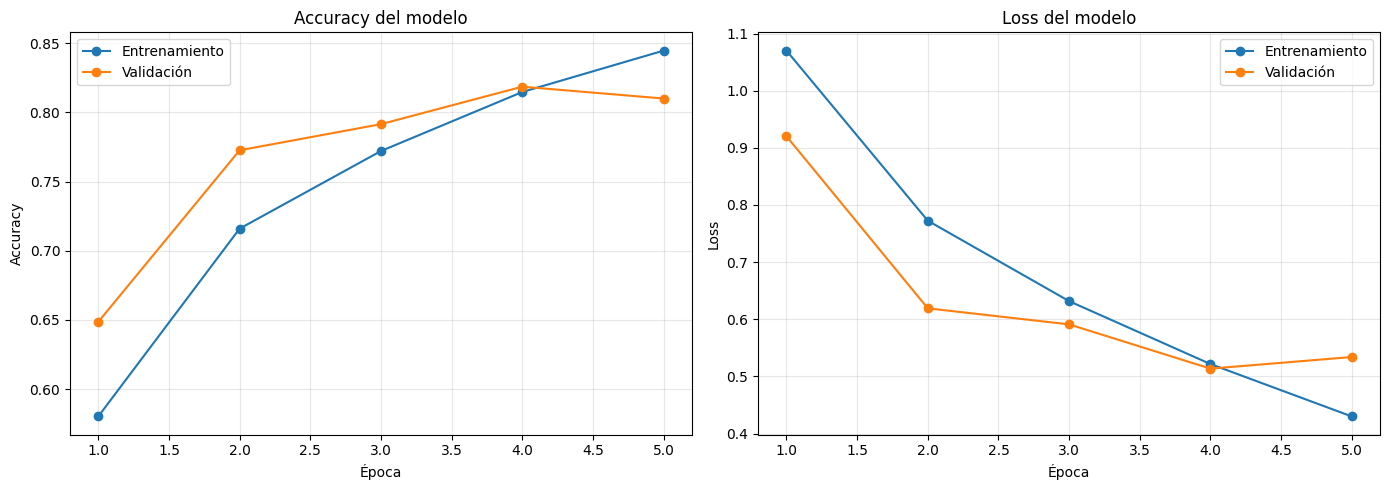

In [ ]:
# Graficas modelo

acc_train = history.history['accuracy']
acc_val = history.history['val_accuracy']
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs_range = range(1, len(acc_train) + 1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc_train, marker='o', label='Entrenamiento')
plt.plot(epochs_range, acc_val, marker='o', label='Validación')
plt.title('Accuracy del modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(epochs_range, loss_train, marker='o', label='Entrenamiento')
plt.plot(epochs_range, loss_val, marker='o', label='Validación')
plt.title('Loss del modelo')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Utilizar predicciones con el conjunto de validacion

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

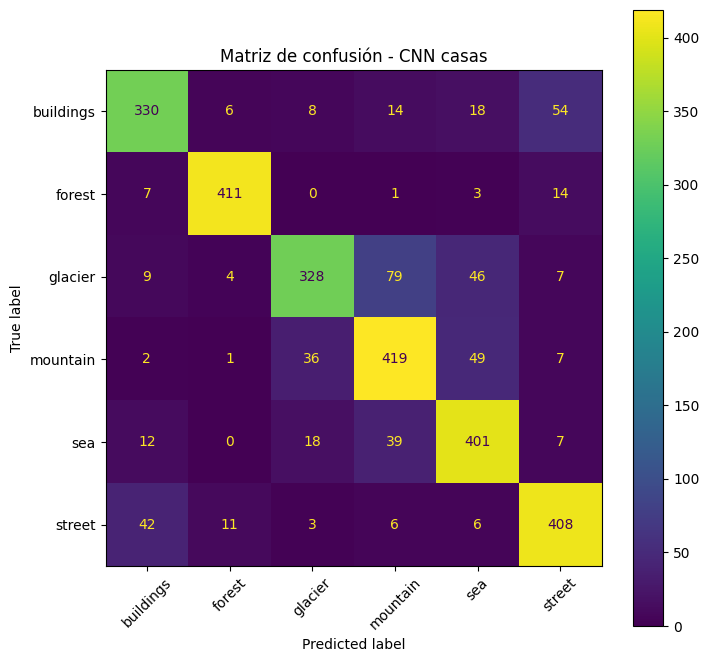

In [ ]:
# Matriz de confusion

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, values_format='d')
plt.title("Matriz de confusión - CNN casas")
plt.show()

In [ ]:
# Reporte

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.82      0.77      0.79       430
      forest       0.95      0.94      0.95       436
     glacier       0.83      0.69      0.76       473
    mountain       0.75      0.82      0.78       514
         sea       0.77      0.84      0.80       477
      street       0.82      0.86      0.84       476

    accuracy                           0.82      2806
   macro avg       0.82      0.82      0.82      2806
weighted avg       0.82      0.82      0.82      2806



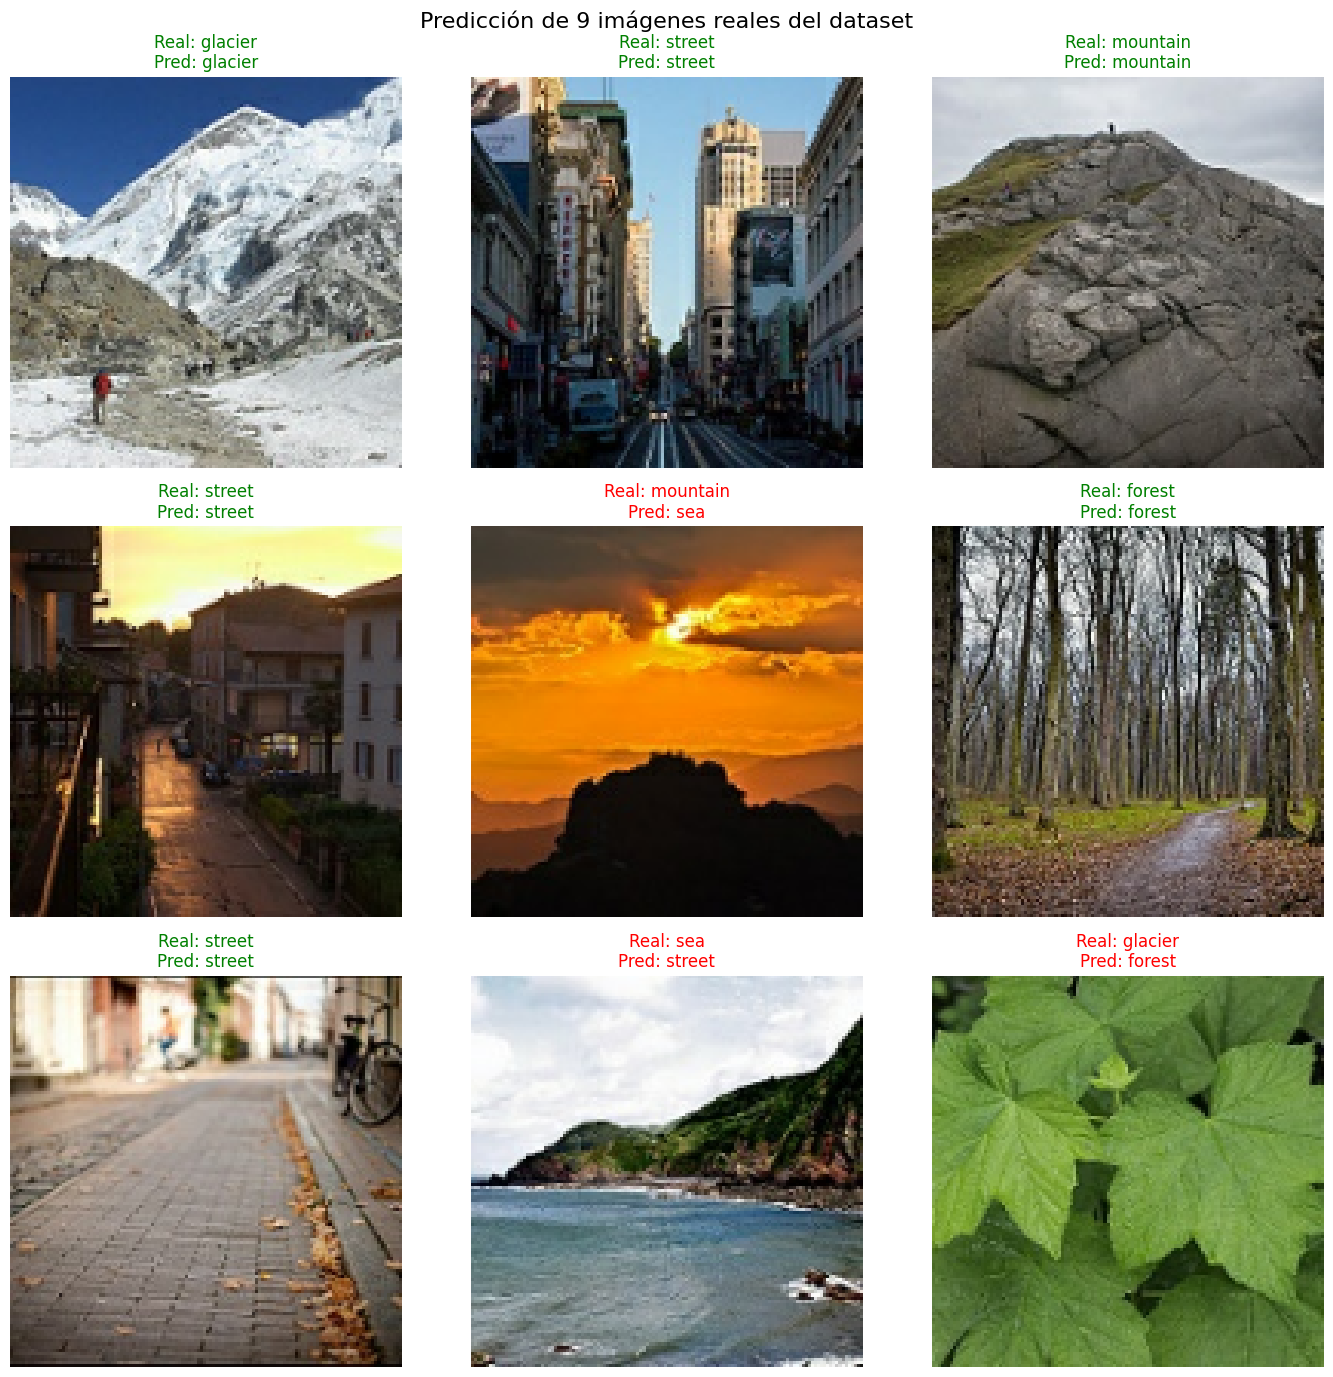

In [ ]:
# Prueba de 9 predicciones real vs predicho

# Tomar un lote del conjunto de validación
for images, labels in val_ds.take(1):
    sample_images = images[:9]
    sample_labels = labels[:9]
    sample_preds = model.predict(sample_images, verbose=0)
    sample_pred_labels = np.argmax(sample_preds, axis=1)

plt.figure(figsize=(14, 14))

for i in range(len(sample_images)):
    plt.subplot(3, 3, i + 1)
    img = sample_images[i].numpy().astype("uint8")
    real = class_names[int(sample_labels[i])]
    pred = class_names[int(sample_pred_labels[i])]

    plt.imshow(img)
    color = "green" if real == pred else "red"
    plt.title(f"Real: {real}\nPred: {pred}", color=color)
    plt.axis("off")

plt.suptitle("Predicción de 9 imágenes reales del dataset", fontsize=16)
plt.tight_layout()
plt.show()

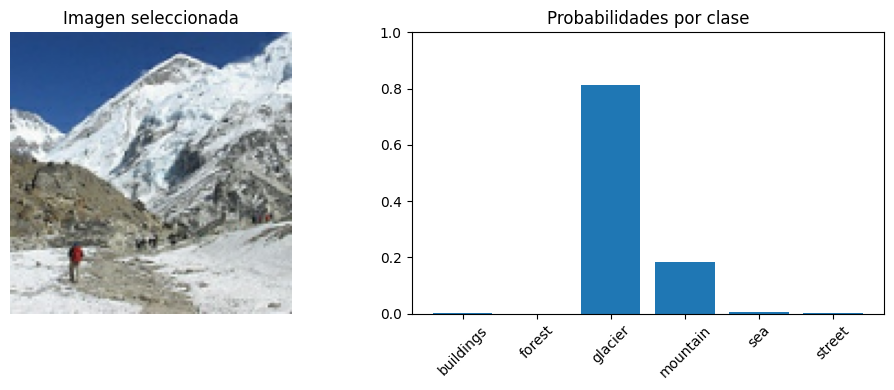

Clase real: glacier
Clase predicha: glacier


In [ ]:
# Probabilidades imagenes individuales

idx = 0
img = np.expand_dims(sample_images[idx], axis=0)
pred = model.predict(img, verbose=0)[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample_images[idx].numpy().astype("uint8"))
plt.title("Imagen seleccionada")
plt.axis("off")

plt.subplot(1,2,2)
plt.bar(class_names, pred)
plt.title("Probabilidades por clase")
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

print("Clase real:", class_names[int(sample_labels[idx])])
print("Clase predicha:", class_names[int(np.argmax(pred))])

# **Ejemplo 4 (DNN)**

In [ ]:
!pip -q install kagglehub

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# 1. Descargar dataset desde Kaggle

path = kagglehub.dataset_download("fedesoriano/the-boston-houseprice-data")
print("Ruta descargada:", path)

root = Path(path)

# Buscar CSV
csv_files = list(root.rglob("*.csv"))
print("Archivos CSV encontrados:", csv_files)

df = pd.read_csv(csv_files[0])
print("\nColumnas:")
print(df.columns.tolist())

print("\nPrimeras n filas:")
print(df.head(20))

Using Colab cache for faster access to the 'the-boston-houseprice-data' dataset.
Ruta descargada: /kaggle/input/the-boston-houseprice-data
Archivos CSV encontrados: [PosixPath('/kaggle/input/the-boston-houseprice-data/boston.csv')]

Columnas:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Primeras n filas:
       CRIM    ZN  INDUS  CHAS    NOX     RM    AGE     DIS  RAD    TAX  \
0   0.00632  18.0   2.31     0  0.538  6.575   65.2  4.0900    1  296.0   
1   0.02731   0.0   7.07     0  0.469  6.421   78.9  4.9671    2  242.0   
2   0.02729   0.0   7.07     0  0.469  7.185   61.1  4.9671    2  242.0   
3   0.03237   0.0   2.18     0  0.458  6.998   45.8  6.0622    3  222.0   
4   0.06905   0.0   2.18     0  0.458  7.147   54.2  6.0622    3  222.0   
5   0.02985   0.0   2.18     0  0.458  6.430   58.7  6.0622    3  222.0   
6   0.08829  12.5   7.87     0  0.524  6.012   66.6  5.5605    5  311.0   
7   0.14455  12.5   7.87     0  

In [ ]:
# 2. Definir X e y

target_col = "MEDV"
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\nNúmero de registros: {len(df)}")
print(f"Número de variables de entrada: {X.shape[1]}")
print(f"Variable objetivo: {target_col}")


Número de registros: 506
Número de variables de entrada: 13
Variable objetivo: MEDV


In [ ]:
# 3. División entrenamiento / prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 4. Escalado

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 5. Modelo DNN para regresión

model_reg = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)  # salida numérica
])

In [ ]:
model_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)

model_reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6. Early stopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [ ]:
# 7. Entrenamiento

history_reg = model_reg.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 594.4129 - mae: 22.4247 - mse: 594.4129 - val_loss: 505.4187 - val_mae: 20.8806 - val_mse: 505.4187
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 511.7230 - mae: 20.5373 - mse: 511.7230 - val_loss: 395.9804 - val_mae: 18.1628 - val_mse: 395.9804
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 355.6826 - mae: 16.4870 - mse: 355.6826 - val_loss: 215.6552 - val_mae: 12.5952 - val_mse: 215.6552
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 170.2513 - mae: 10.2322 - mse: 170.2513 - val_loss: 72.4202 - val_mae: 5.8356 - val_mse: 72.4202
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 82.7278 - mae: 6.9350 - mse: 82.7278 - val_loss: 42.4620 - val_mae: 4.3357 - val_mse: 42.4620
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 54.3009 - mae: 5.4629 - mse: 54.3009 - val_loss: 31.6986 - val_mae: 3.5924 - val_mse: 31.6986
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3

In [ ]:
# 8. Evaluación

y_pred = model_reg.predict(X_test_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nResultados del modelo de regresión")
print("-" * 40)
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


Resultados del modelo de regresión
----------------------------------------
MAE : 2.4297
MSE : 13.0802
RMSE: 3.6167
R²  : 0.8216


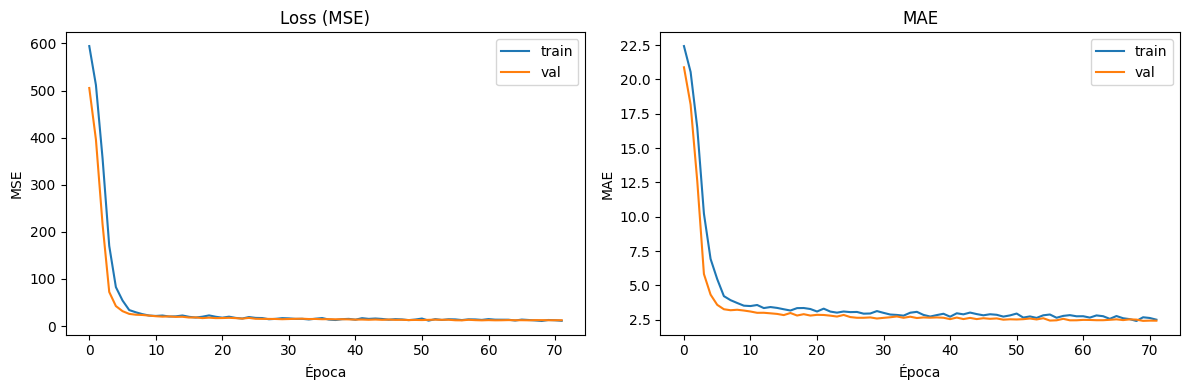

In [ ]:
# 9. Gráficas de entrenamiento

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_reg.history['loss'], label='train')
plt.plot(history_reg.history['val_loss'], label='val')
plt.title("Loss (MSE)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_reg.history['mae'], label='train')
plt.plot(history_reg.history['val_mae'], label='val')
plt.title("MAE")
plt.xlabel("Época")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# 10. Tabla de ejemplo

n_inicio = 50 ;
n_fin = 60 ;

resultados_reg = pd.DataFrame({
    "Real": y_test.values[n_inicio:n_fin],
    "Predicho": y_pred[n_inicio:n_fin],
    "Error": y_test.values[n_inicio:n_fin] - y_pred[n_inicio:n_fin]
})
print("\nPrimeras predicciones:")
print(resultados_reg)


Primeras predicciones:
   Real   Predicho     Error
0  18.9  18.655664  0.244336
1  35.4  35.182186  0.217814
2  15.2  15.836093 -0.636093
3  26.5  25.392469  1.107531
4  43.5  42.655346  0.844654
5  21.2  23.923849 -2.723849
6  18.4  17.902853  0.497147
7  28.5  32.225971 -3.725971
8  23.9  25.415545 -1.515545
9  18.5  13.972328  4.527672


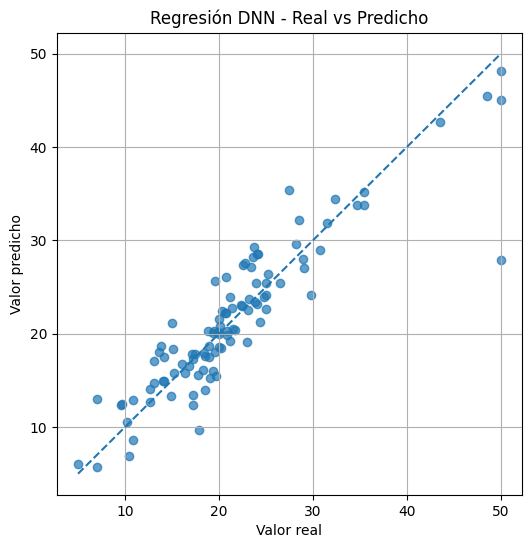

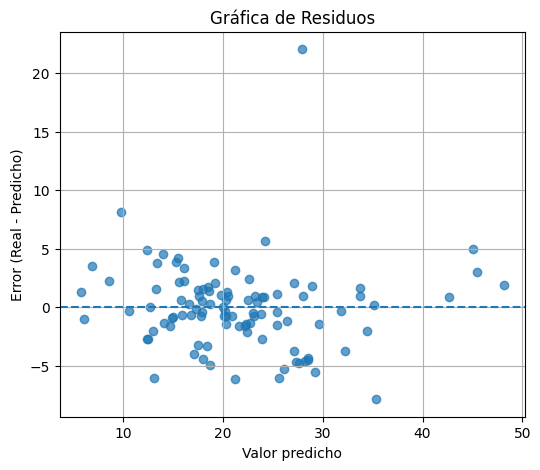

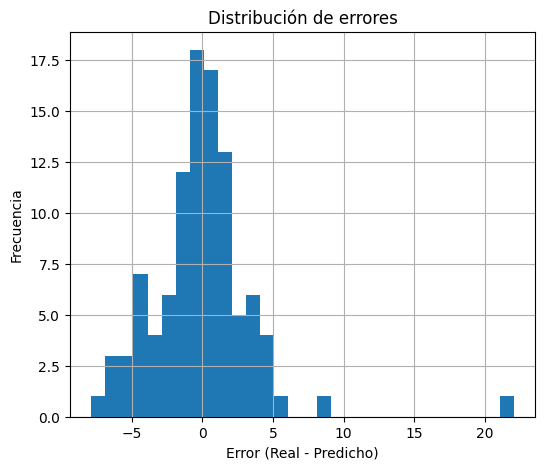

In [ ]:
# 11. Real vs Predicho

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--')
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresión DNN - Real vs Predicho")
plt.grid(True)
plt.show()



residuos = y_test - y_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuos, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Valor predicho")
plt.ylabel("Error (Real - Predicho)")
plt.title("Gráfica de Residuos")
plt.grid(True)
plt.show()






plt.figure(figsize=(6, 5))
plt.hist(residuos, bins=30)
plt.xlabel("Error (Real - Predicho)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores")
plt.grid(True)
plt.show()

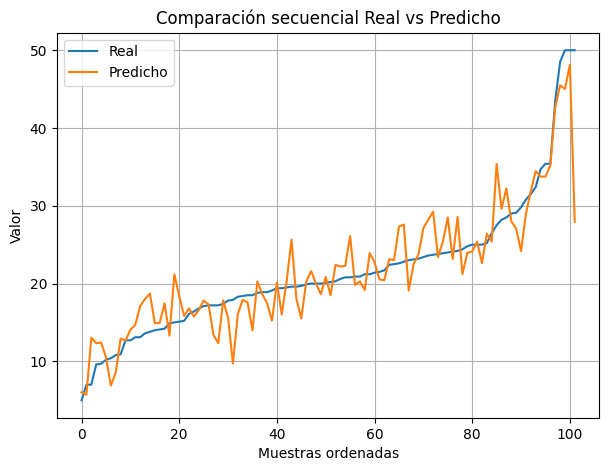

In [ ]:
# Ordenar por valores reales
sorted_idx = np.argsort(y_test)

y_test_sorted = y_test.values[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(7,5))
plt.plot(y_test_sorted, label="Real")
plt.plot(y_pred_sorted, label="Predicho")
plt.xlabel("Muestras ordenadas")
plt.ylabel("Valor")
plt.title("Comparación secuencial Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

# **Ejemplo 5 (RNN)**

In [ ]:
!pip -q install kagglehub

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf

from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# 1. Descargar dataset desde Kaggle

path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
print("Ruta descargada:", path)

root = Path(path)
csv_files = list(root.rglob("*.csv"))
print("CSV encontrados:", csv_files)

# Normalmente trae train y test
for f in csv_files:
    print(f.name)

# Cargar train y test
train_file = [f for f in csv_files if "Train" in f.name or "train" in f.name][0]
test_file  = [f for f in csv_files if "Test" in f.name or "test" in f.name][0]

df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

print("\nTrain:")
print(df_train.head())

print("\nTest:")
print(df_test.head())

100%|██████████| 22.0k/22.0k [00:00<00:00, 28.6MB/s]

Extracting files...
Ruta descargada: /root/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3
CSV encontrados: [PosixPath('/root/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTest.csv'), PosixPath('/root/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTrain.csv')]
DailyDelhiClimateTest.csv
DailyDelhiClimateTrain.csv

Train:
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000

Test:
         date   meantemp   humidity  wind_speed  meanpressure
0  2017-01-01  15.913043  85.869565    2.743478     59.000000
1  2017-01-02  18.500000  77.222222    2.8

In [ ]:
# 2. Unir datasets para facilitar preprocesamiento

df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

# Convertir fecha
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("\nColumnas:", df.columns.tolist())
print("\nValores nulos:")
print(df.isnull().sum())


Columnas: ['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']

Valores nulos:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [ ]:
# 3. Seleccionar variables

features = ["meantemp", "humidity", "wind_speed", "meanpressure"]
target = "meantemp"

data = df[features].copy()

In [ ]:
# 4. Escalado

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
# 5. Crear secuencias

window_size = 30

X = []
y = []

for i in range(window_size, len(data_scaled)):
    X.append(data_scaled[i-window_size:i])
    y.append(data_scaled[i, 0])  # 0 corresponde a meantemp

X = np.array(X)
y = np.array(y)

print("\nForma de X:", X.shape)   # (muestras, ventana, variables)
print("Forma de y:", y.shape)


Forma de X: (1546, 30, 4)
Forma de y: (1546,)


In [ ]:
# 6. División train/test temporal


train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("\nTrain:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (1236, 30, 4) (1236,)
Test : (310, 30, 4) (310,)


In [ ]:
# 7. Modelo RNN simple

model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 8. Early stopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
# 9. Entrenamiento

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0521 - mae: 0.1592 - val_loss: 0.0108 - val_mae: 0.0837
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0077 - mae: 0.0700 - val_loss: 0.0061 - val_mae: 0.0630
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0051 - mae: 0.0567 - val_loss: 0.0048 - val_mae: 0.0545
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0043 - mae: 0.0515 - val_loss: 0.0042 - val_mae: 0.0501
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0039 - mae: 0.0496 - val_loss: 0.0041 - val_mae: 0.0480
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0040 - mae: 0.0505 - val_loss: 0.0040 - val_mae: 0.0488
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0034 - mae: 0.0459 - val_loss: 0.0036 - val_mae: 0.0459
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0037 - mae: 0.0479 - val_loss: 0.0060 - val_mae: 0.0632
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss:

In [ ]:
# 10. Predicción

y_pred = model.predict(X_test, verbose=0)

In [ ]:
# 11. Invertir escala solo para la variable objetivo

def invert_target_scaling(y_scaled, scaler_obj, n_features):
    aux = np.zeros((len(y_scaled), n_features))
    aux[:, 0] = y_scaled.reshape(-1)
    return scaler_obj.inverse_transform(aux)[:, 0]

y_test_inv = invert_target_scaling(y_test, scaler, len(features))
y_pred_inv = invert_target_scaling(y_pred.reshape(-1), scaler, len(features))

In [ ]:
# 12. Métricas

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print("\nResultados RNN")
print("-" * 40)
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


Resultados RNN
----------------------------------------
MAE : 1.3391
MSE : 3.0170
RMSE: 1.7370
R²  : 0.9292


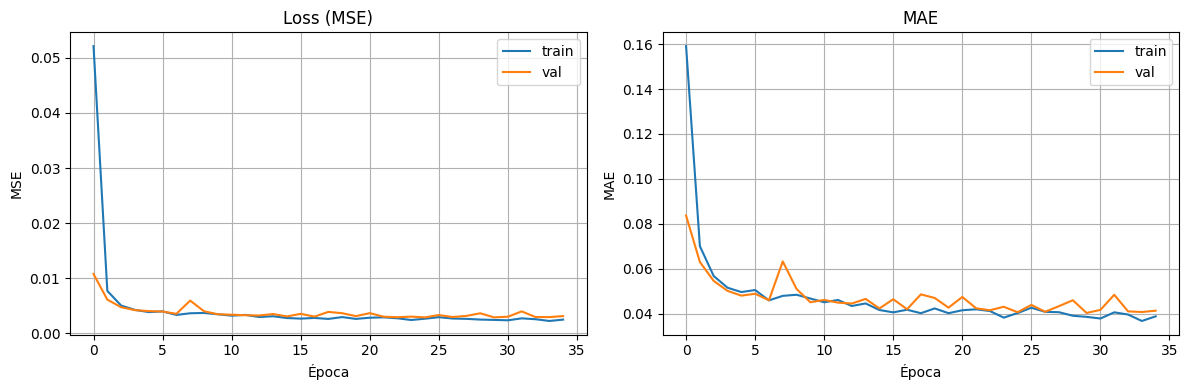

In [ ]:
# 13. Gráficas de entrenamiento

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss (MSE)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val")
plt.title("MAE")
plt.xlabel("Época")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

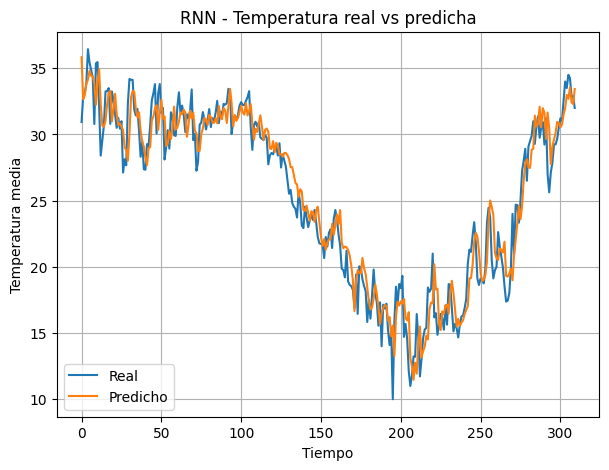

In [ ]:
# 14. Real vs Predicho

plt.figure(figsize=(7,5))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.title("RNN - Temperatura real vs predicha")
plt.xlabel("Tiempo")
plt.ylabel("Temperatura media")
plt.legend()
plt.grid(True)
plt.show()

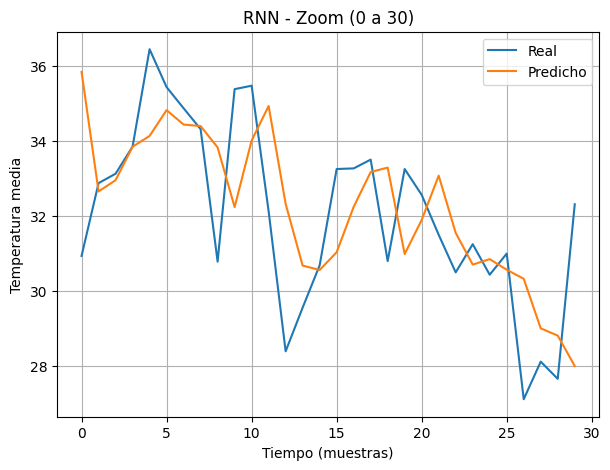

In [ ]:
# Definir rango de zoom
inicio = 0
fin = 30

plt.figure(figsize=(7,5))
plt.plot(y_test_inv[inicio:fin], label="Real")
plt.plot(y_pred_inv[inicio:fin], label="Predicho")

plt.title(f"RNN - Zoom ({inicio} a {fin})")
plt.xlabel("Tiempo (muestras)")
plt.ylabel("Temperatura media")
plt.legend()
plt.grid(True)
plt.show()

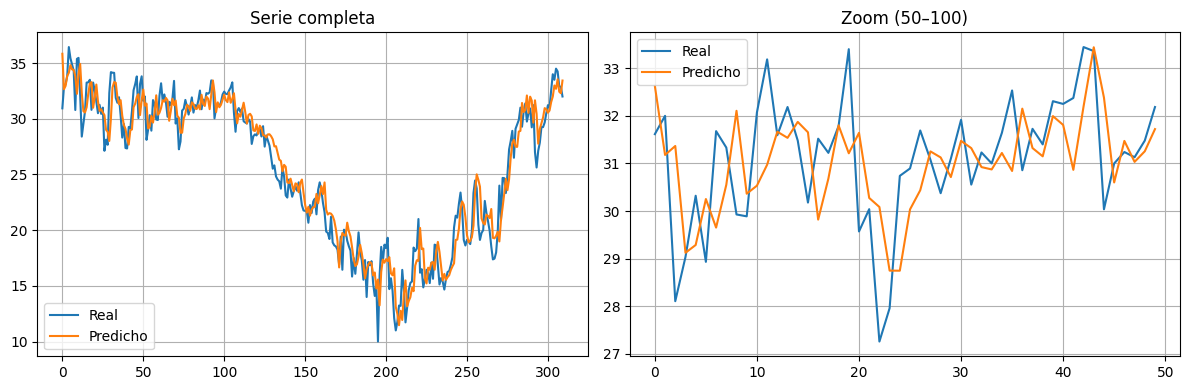

In [ ]:
plt.figure(figsize=(12,4))

# Global
plt.subplot(1,2,1)
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.title("Serie completa")
plt.legend()
plt.grid(True)

# Zoom
plt.subplot(1,2,2)
plt.plot(y_test_inv[50:100], label="Real")
plt.plot(y_pred_inv[50:100], label="Predicho")
plt.title("Zoom (50–100)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

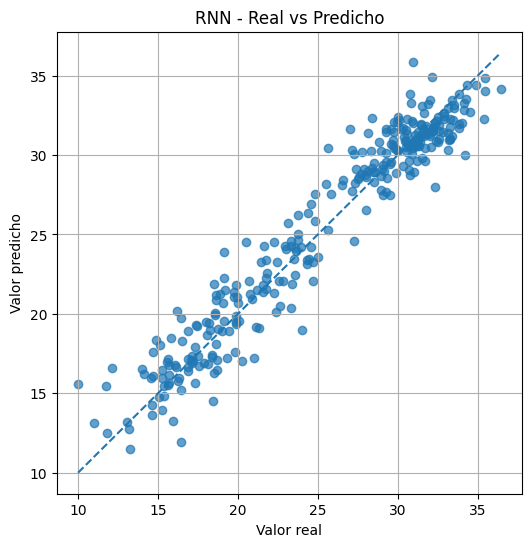

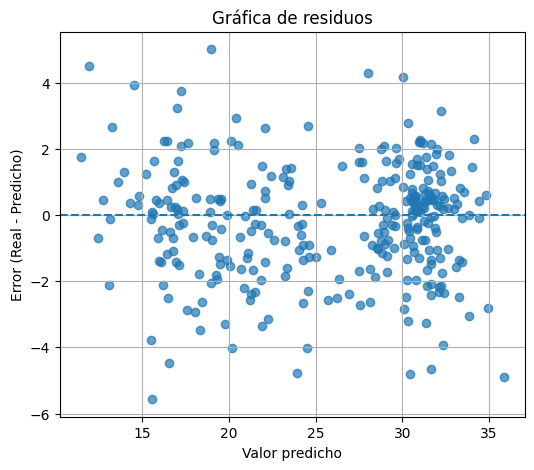

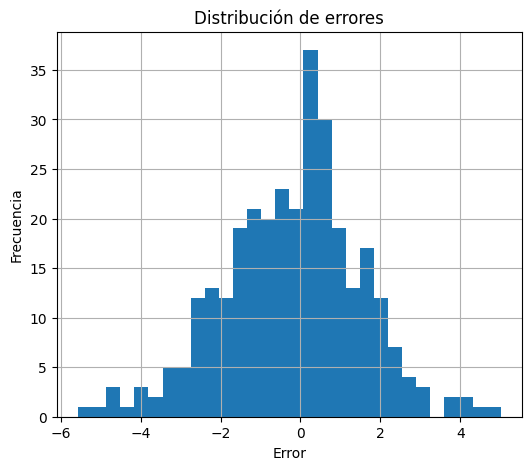

In [ ]:
# 15. Scatter Real vs Predicho

plt.figure(figsize=(6,6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.7)
plt.plot([y_test_inv.min(), y_test_inv.max()],
         [y_test_inv.min(), y_test_inv.max()],
         '--')
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("RNN - Real vs Predicho")
plt.grid(True)
plt.show()

# 16. Residuos

residuos = y_test_inv - y_pred_inv

plt.figure(figsize=(6,5))
plt.scatter(y_pred_inv, residuos, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Valor predicho")
plt.ylabel("Error (Real - Predicho)")
plt.title("Gráfica de residuos")
plt.grid(True)
plt.show()



# 17. Histograma de errores
plt.figure(figsize=(6,5))
plt.hist(residuos, bins=30)
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores")
plt.grid(True)
plt.show()
